In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##**Imports and set up**

Impoting all required libraries for data handling , freature extraction , model training and evaluation

In [ ]:
 # Core
import re
import string
import random
import numpy as np
import pandas as pd

# Data splitting & feature extraction
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Evaluation metrics
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# PyTorch
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler


# Plotting (for validation loss curves, confusion matrices)
import matplotlib.pyplot as plt

**1 Data loading**
Loading the MasakhaNEWS dataset for the three target languages :

In [ ]:
DATA_PATH = "/content/drive/MyDrive/news-dataset"

def load_language(language):
    train = pd.read_csv(f"{DATA_PATH}/{language}/train.tsv", sep="\t")
    dev   = pd.read_csv(f"{DATA_PATH}/{language}/dev.tsv",   sep="\t")
    test  = pd.read_csv(f"{DATA_PATH}/{language}/test.tsv",  sep="\t")
    return train, dev, test

eng_train, eng_dev, eng_test = load_language("eng")
xho_train, xho_dev, xho_test = load_language("xho")
sna_train, sna_dev, sna_test = load_language("sna")

print("Data loaded successfully!")
print("English train size:", len(eng_train))

Data loaded successfully!
English train size: 3309


##Text Processing
Label Encoding

Converting he categorical news topics into integer labels using labelEncoder. The encoder if fitted only on the training set to avoid data leakage

In [ ]:
# 1. Create full_text
def create_full_text(df):
    return df["headline"].fillna("") + " " + df["text"].fillna("")


eng_train["full_text"] = create_full_text(eng_train)
eng_dev["full_text"]   = create_full_text(eng_dev)
eng_test["full_text"]  = create_full_text(eng_test)


# 2. Clean text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


eng_train_text = eng_train["full_text"].apply(clean_text)
eng_dev_text   = eng_dev["full_text"].apply(clean_text)
eng_test_text  = eng_test["full_text"].apply(clean_text)


# 3. Encode the category labels
LABEL_COL = "category"

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(eng_train[LABEL_COL])
y_dev   = label_encoder.transform(eng_dev[LABEL_COL])
y_test  = label_encoder.transform(eng_test[LABEL_COL])


# Check what happened
print("Classes:", list(label_encoder.classes_))
print("Number of classes:", len(label_encoder.classes_))

Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
Number of classes: 6


##Feature Extraction -Bag-of-words
Converting the cleaned text into numerical vectors using a countVectoriser

In [ ]:
# 4. Feature extraction (start with Bag-of-Words)
vectorizer = CountVectorizer(
    max_features=5000,
    min_df=3
)

X_train = vectorizer.fit_transform(eng_train_text)
X_dev   = vectorizer.transform(eng_dev_text)
X_test  = vectorizer.transform(eng_test_text)

print("Vocabulary size:", len(vectorizer.vocabulary_))
print("X_train shape:", X_train.shape)

# 5. Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train.toarray(), dtype=torch.float32)
X_dev_tensor   = torch.tensor(X_dev.toarray(),   dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test.toarray(),  dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_dev_tensor   = torch.tensor(y_dev,   dtype=torch.long)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.long)

print("\nTensors ready!")
print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)

Vocabulary size: 5000
X_train shape: (3309, 5000)

Tensors ready!
X_train_tensor: torch.Size([3309, 5000])
y_train_tensor: torch.Size([3309])


##Convert to pytorch Tensors


In [ ]:
def prepare_language(
    train_df,
    dev_df,
    test_df,
    max_features=5000,
    min_df=3,
    vectorizer_type="count"
):
    # 1. Create and clean full text
    train_text = (
        train_df["headline"].fillna("") + " " +
        train_df["text"].fillna("")
    ).apply(clean_text)

    dev_text = (
        dev_df["headline"].fillna("") + " " +
        dev_df["text"].fillna("")
    ).apply(clean_text)

    test_text = (
        test_df["headline"].fillna("") + " " +
        test_df["text"].fillna("")
    ).apply(clean_text)

    # 2. Encode labels
    le = LabelEncoder()

    y_train = le.fit_transform(train_df["category"])
    y_dev   = le.transform(dev_df["category"])
    y_test  = le.transform(test_df["category"])

    # 3. Choose feature extractor
    if vectorizer_type == "count":
        vectorizer = CountVectorizer(
            max_features=max_features,
            min_df=min_df
        )
    elif vectorizer_type == "tfidf":
        vectorizer = TfidfVectorizer(
            max_features=max_features,
            min_df=min_df
        )
    else:
        raise ValueError(
            "vectorizer_type must be 'count' or 'tfidf'"
        )

    # 4. Fit only on training data
    X_train = vectorizer.fit_transform(train_text)

    # Use the same vocabulary for dev and test
    X_dev = vectorizer.transform(dev_text)
    X_test = vectorizer.transform(test_text)

    # 5. Convert features to PyTorch tensors
    X_train_t = torch.tensor(
        X_train.toarray(), dtype=torch.float32
    )
    X_dev_t = torch.tensor(
        X_dev.toarray(), dtype=torch.float32
    )
    X_test_t = torch.tensor(
        X_test.toarray(), dtype=torch.float32
    )

    # 6. Convert labels to PyTorch tensors
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_dev_t   = torch.tensor(y_dev, dtype=torch.long)
    y_test_t  = torch.tensor(y_test, dtype=torch.long)

    print(
        f"Prepared data → features: {X_train_t.shape[1]}, "
        f"classes: {len(le.classes_)}"
    )
    print(f"Classes: {list(le.classes_)}")

    return {
        "X_train": X_train_t,
        "y_train": y_train_t,
        "X_dev": X_dev_t,
        "y_dev": y_dev_t,
        "X_test": X_test_t,
        "y_test": y_test_t,
        "vectorizer": vectorizer,
        "label_encoder": le,
        "num_classes": len(le.classes_),
        "input_dim": X_train_t.shape[1]
    }

## 2 Mutinomial Logistic Regression Model
This is the implementation of the mutlinomial logistic Regresstion

In [ ]:
class MultinomialLogisticRegression(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        """Process a batch of inputs during training (returns logits)."""
        return self.linear(x)

    def compute_probabilities(self, x):
        """Compute class probabilities for a batch of inputs."""
        logits = self.forward(x)
        return F.softmax(logits, dim=1)

    def predict(self, x):
        """Return the predicted class indices for a batch of inputs."""
        probs = self.compute_probabilities(x)
        return torch.argmax(probs, dim=1)

##Mutinomial logistic Regression class

In [ ]:
input_dim = X_train_tensor.shape[1]
num_classes = len(label_encoder.classes_)

model = MultinomialLogisticRegression(input_dim, num_classes)

# Quick sanity check
with torch.no_grad():
    logits = model(X_train_tensor[:5])
    probs  = model.compute_probabilities(X_train_tensor[:5])
    preds  = model.predict(X_train_tensor[:5])

print("Logits shape:", logits.shape)
print("Probs shape:", probs.shape)
print("Preds:", preds)

Logits shape: torch.Size([5, 6])
Probs shape: torch.Size([5, 6])
Preds: tensor([3, 5, 0, 4, 3])


In [ ]:
import copy

def train_model(
    model,
    X_train, y_train,
    X_dev, y_dev,
    lr=0.01,
    batch_size=32,
    num_epochs=50,
    patience=5,
    verbose=True
):
    # Loss function
    criterion = nn.CrossEntropyLoss()

    # Gradient descent optimizer
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr
    )

    # Mini-batch training data
    train_dataset = TensorDataset(X_train, y_train)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # Track the best validation performance
    best_val_acc = 0.0
    best_model_state = None
    epochs_without_improvement = 0

    # Store results for analysis/plots
    train_losses = []
    val_accuracies = []

    # Training loop
    for epoch in range(num_epochs):

        # ---- Training ----
        model.train()
        epoch_loss = 0.0

        for X_batch, y_batch in train_loader:

            # Clear previous gradients
            optimizer.zero_grad()

            # Forward pass
            logits = model(X_batch)

            # Calculate cross-entropy loss
            loss = criterion(logits, y_batch)

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            epoch_loss += loss.item()

        # Average loss for this epoch
        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ---- Validation ----
        model.eval()

        with torch.no_grad():
            val_preds = model.predict(X_dev)

            val_acc = (
                (val_preds == y_dev)
                .float()
                .mean()
                .item()
            )

        val_accuracies.append(val_acc)

        # Print progress
        if verbose:
            print(
                f"Epoch {epoch + 1:3d} | "
                f"Train Loss: {avg_train_loss:.4f} | "
                f"Val Acc: {val_acc:.4f}"
            )

        # ---- Early stopping ----
        if val_acc > best_val_acc:

            best_val_acc = val_acc

            # Make a deep copy of the best weights
            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

            if epochs_without_improvement >= patience:

                if verbose:
                    print(
                        f"Early stopping at epoch {epoch + 1}"
                    )

                break

    # Restore the best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return {
        "train_losses": train_losses,
        "val_accuracies": val_accuracies,
        "best_val_acc": best_val_acc
    }

In [ ]:
# Prepare English data with Bag-of-Words
eng_bow = prepare_language(
    eng_train, eng_dev, eng_test,
    max_features=5000,
    min_df=3,
    vectorizer_type="count"
)

Prepared data → features: 5000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']


In [ ]:
# Create model
model = MultinomialLogisticRegression(
    input_dim=eng_bow["input_dim"],
    num_classes=eng_bow["num_classes"]
)

# Train
history = train_model(
    model,
    eng_bow["X_train"], eng_bow["y_train"],
    eng_bow["X_dev"],   eng_bow["y_dev"],
    lr=0.1,
    batch_size=64,
    num_epochs=100,
    patience=7,
    verbose=True
)

print(f"\nBest validation accuracy: {history['best_val_acc']:.4f}")

Epoch   1 | Train Loss: 33.8954 | Val Acc: 0.4534
Epoch   2 | Train Loss: 10.3815 | Val Acc: 0.6547
Epoch   3 | Train Loss: 4.2820 | Val Acc: 0.6949
Epoch   4 | Train Loss: 2.3919 | Val Acc: 0.6822
Epoch   5 | Train Loss: 1.6483 | Val Acc: 0.7987
Epoch   6 | Train Loss: 2.1875 | Val Acc: 0.7203
Epoch   7 | Train Loss: 1.6867 | Val Acc: 0.8538
Epoch   8 | Train Loss: 0.8756 | Val Acc: 0.8453
Epoch   9 | Train Loss: 0.5722 | Val Acc: 0.7881
Epoch  10 | Train Loss: 0.9057 | Val Acc: 0.8559
Epoch  11 | Train Loss: 0.9710 | Val Acc: 0.7097
Epoch  12 | Train Loss: 1.0952 | Val Acc: 0.7331
Epoch  13 | Train Loss: 0.2933 | Val Acc: 0.8538
Epoch  14 | Train Loss: 0.2873 | Val Acc: 0.8538
Epoch  15 | Train Loss: 0.3217 | Val Acc: 0.8729
Epoch  16 | Train Loss: 0.1045 | Val Acc: 0.8665
Epoch  17 | Train Loss: 0.0999 | Val Acc: 0.8644
Epoch  18 | Train Loss: 0.0753 | Val Acc: 0.8623
Epoch  19 | Train Loss: 0.0534 | Val Acc: 0.8602
Epoch  20 | Train Loss: 0.0571 | Val Acc: 0.8686
Epoch  21 | Train 

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(model, X, y, label_encoder, title="Test"):
    model.eval()
    with torch.no_grad():
        preds = model.predict(X).cpu().numpy()

    y_true = y.cpu().numpy()

    acc = accuracy_score(y_true, preds)
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(y_true, preds, average="micro")
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_true, preds, average="macro")

    print(f"\n===== {title} Results =====")
    print(f"Accuracy       : {acc:.4f}")
    print(f"Precision (micro): {precision_micro:.4f} | (macro): {precision_macro:.4f}")
    print(f"Recall    (micro): {recall_micro:.4f} | (macro): {recall_macro:.4f}")
    print(f"F1        (micro): {f1_micro:.4f} | (macro): {f1_macro:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix - {title}")
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "precision_micro": precision_micro, "precision_macro": precision_macro,
        "recall_micro": recall_micro, "recall_macro": recall_macro,
        "f1_micro": f1_micro, "f1_macro": f1_macro
    }


===== English BoW Test Results =====
Accuracy       : 0.8892
Precision (micro): 0.8892 | (macro): 0.8860
Recall    (micro): 0.8892 | (macro): 0.8849
F1        (micro): 0.8892 | (macro): 0.8844


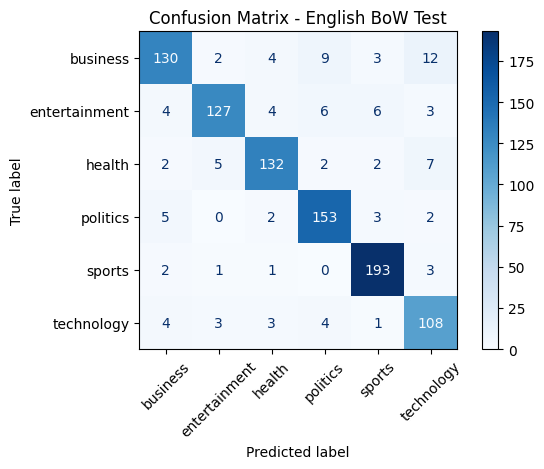

In [ ]:
test_results = evaluate_model(
    model,
    eng_bow["X_test"],
    eng_bow["y_test"],
    eng_bow["label_encoder"],
    title="English BoW Test"
)

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print("Random seed set to 42")

Random seed set to 42


## 4. Baseline Experiments

We train multinomial logistic regression models for all three languages (English, isiXhosa, and chiShona) using both feature extraction methods:

- Bag-of-Words (`CountVectorizer`)
- TF-IDF (`TfidfVectorizer`)

These baseline models use fixed hyperparameters and will serve as a reference point before hyperparameter tuning.


Training ENG with COUNT
Prepared data → features: 5000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']

===== ENG COUNT Test Results =====
Accuracy       : 0.8882
Precision (micro): 0.8882 | (macro): 0.8838
Recall    (micro): 0.8882 | (macro): 0.8827
F1        (micro): 0.8882 | (macro): 0.8828


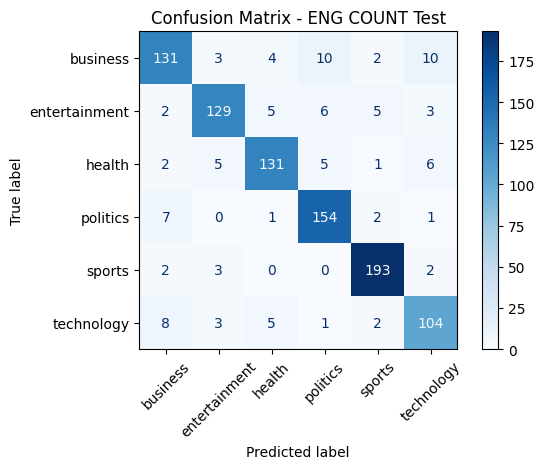


Training ENG with TFIDF
Prepared data → features: 5000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']

===== ENG TFIDF Test Results =====
Accuracy       : 0.8481
Precision (micro): 0.8481 | (macro): 0.8540
Recall    (micro): 0.8481 | (macro): 0.8357
F1        (micro): 0.8481 | (macro): 0.8404


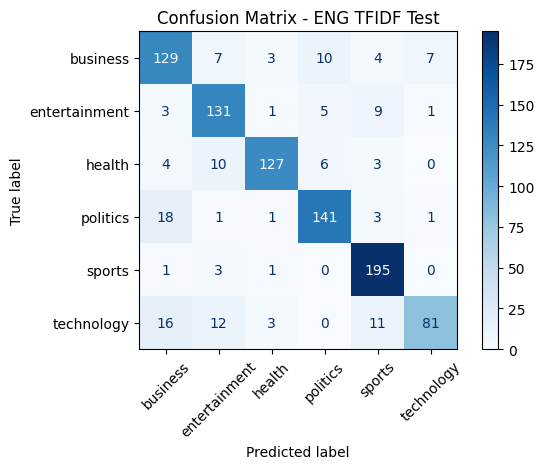


Training XHO with COUNT
Prepared data → features: 5000, classes: 5
Classes: ['business', 'entertainment', 'health', 'politics', 'sports']

===== XHO COUNT Test Results =====
Accuracy       : 0.8923
Precision (micro): 0.8923 | (macro): 0.8837
Recall    (micro): 0.8923 | (macro): 0.7475
F1        (micro): 0.8923 | (macro): 0.7874


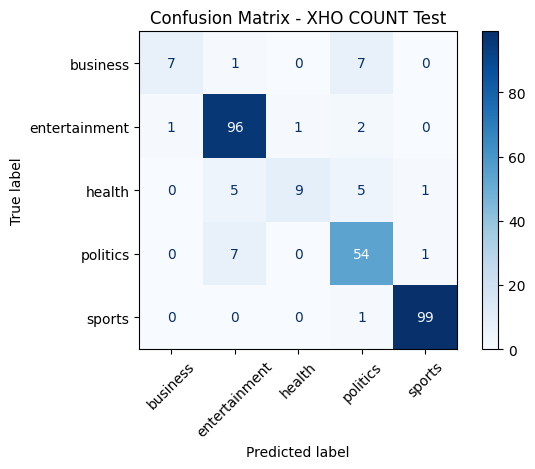


Training XHO with TFIDF
Prepared data → features: 5000, classes: 5
Classes: ['business', 'entertainment', 'health', 'politics', 'sports']

===== XHO TFIDF Test Results =====
Accuracy       : 0.6633
Precision (micro): 0.6633 | (macro): 0.3000
Recall    (micro): 0.6633 | (macro): 0.3940
F1        (micro): 0.6633 | (macro): 0.3303


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


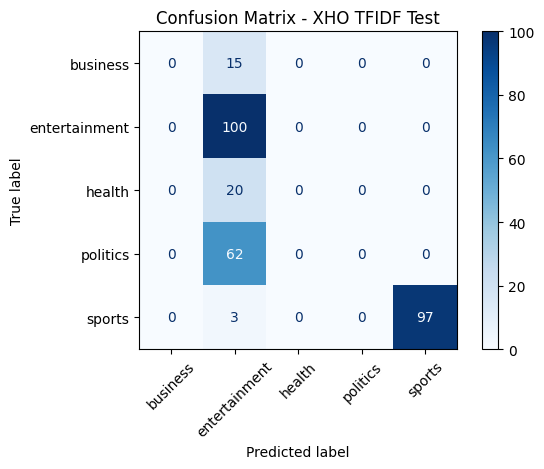


Training SNA with COUNT
Prepared data → features: 5000, classes: 4
Classes: ['business', 'health', 'politics', 'sports']

===== SNA COUNT Test Results =====
Accuracy       : 0.9133
Precision (micro): 0.9133 | (macro): 0.9195
Recall    (micro): 0.9133 | (macro): 0.9142
F1        (micro): 0.9133 | (macro): 0.9162


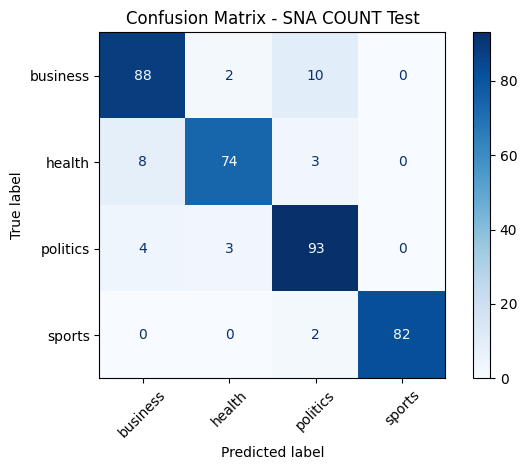


Training SNA with TFIDF
Prepared data → features: 5000, classes: 4
Classes: ['business', 'health', 'politics', 'sports']

===== SNA TFIDF Test Results =====
Accuracy       : 0.8808
Precision (micro): 0.8808 | (macro): 0.9001
Recall    (micro): 0.8808 | (macro): 0.8776
F1        (micro): 0.8808 | (macro): 0.8808


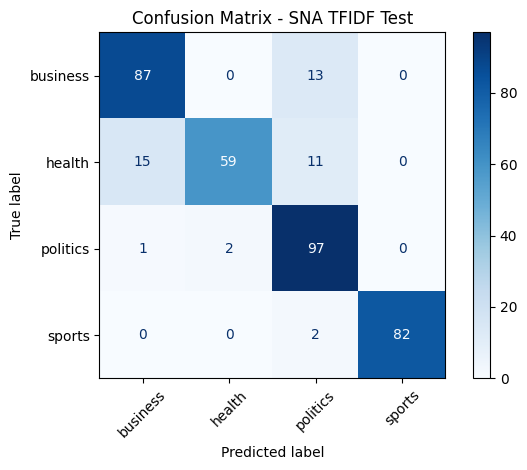



ALL baseline models finished


In [ ]:
languages = {
    "eng": (eng_train, eng_dev, eng_test),
    "xho": (xho_train, xho_dev, xho_test),
    "sna": (sna_train, sna_dev, sna_test)
}

# Storing the results
baseline_results = {}

for lang_name, (train_df, dev_df, test_df) in languages.items():
    for vec_type in ["count", "tfidf"]:          # ← this line was broken

        print(f"\n{'='*60}")
        print(f"Training {lang_name.upper()} with {vec_type.upper()}")
        print(f"{'='*60}")

        # 1. Prepare data
        data = prepare_language(
            train_df, dev_df, test_df,
            max_features=5000,
            min_df=3,
            vectorizer_type=vec_type
        )

        # 2. Create model
        model = MultinomialLogisticRegression(
            input_dim=data["input_dim"],
            num_classes=data["num_classes"]
        )

        # 3. Train
        history = train_model(
            model,
            data["X_train"], data["y_train"],
            data["X_dev"],   data["y_dev"],
            lr=0.1,
            batch_size=64,
            num_epochs=100,
            patience=7,
            verbose=False
        )

        # 4. Evaluate on test set
        test_results = evaluate_model(
            model,
            data["X_test"],
            data["y_test"],
            data["label_encoder"],
            title=f"{lang_name.upper()} {vec_type.upper()} Test"
        )

        # 5. Save everything
        baseline_results[f"{lang_name}_{vec_type}"] = {
            "data": data,
            "model": model,
            "history": history,
            "test_results": test_results
        }

print("\n\nALL baseline models finished")

## Summary of Baseline Results

Create a summary table of the baseline model results for each language
and feature representation. The results stored in `baseline_results`
contain the validation and test performance for each experiment.

This code extracts:
- Best validation accuracy
- Test accuracy
- Macro-averaged F1
- Micro-averaged F1

The metrics are combined into a Pandas DataFrame and sorted by test
accuracy in descending order so that the best-performing baseline
models appear first.

In [ ]:
baseline_summary = []

for key, result in baseline_results.items():
    lang, vec_type = key.split("_")   # split "eng_count" → ["eng", "count"]

    baseline_summary.append({
        "Language": lang,
        "Features": vec_type,
        "Val Accuracy": result["history"]["best_val_acc"],
        "Test Accuracy": result["test_results"]["accuracy"],
        "Test F1 (macro)": result["test_results"]["f1_macro"],
        "Test F1 (micro)": result["test_results"]["f1_micro"]
    })

baseline_summary = pd.DataFrame(baseline_summary)

display(
    baseline_summary
    .sort_values("Test Accuracy", ascending=False)
    .reset_index(drop=True)
)

,Language,Features,Val Accuracy,Test Accuracy,Test F1 (macro),Test F1 (micro)
0,sna,count,0.897297,0.913279,0.916155,0.913279
1,xho,count,0.911565,0.892256,0.787372,0.892256
2,eng,count,0.885593,0.888186,0.882846,0.888186
3,sna,tfidf,0.870270,0.880759,0.880817,0.880759
4,eng,tfidf,0.853814,0.848101,0.840426,0.848101
5,xho,tfidf,0.666667,0.663300,0.330288,0.663300


## 5. Hyperparameter Tuning

Tunning hyperparameters for each language and feature extraction method:
- Learning rate
- Batch size
- Vocabulary size (`max_features`)
- Minimum document frequency (`min_df`)

The best configuration is selected based on **validation accuracy**.

In [ ]:
baseline_summary = []

for key, result in baseline_results.items():
    lang, vec_type = key.split("_")

    baseline_summary.append({
        "Language": lang,
        "Features": vec_type,
        "Val Accuracy": result["history"]["best_val_acc"],
        "Test Accuracy": result["test_results"]["accuracy"],
        "Test F1 (macro)": result["test_results"]["f1_macro"],
        "Test F1 (micro)": result["test_results"]["f1_micro"]
    })

baseline_summary = pd.DataFrame(baseline_summary)

display(
    baseline_summary
    .sort_values("Test Accuracy", ascending=False)
    .reset_index(drop=True)
)

,Language,Features,Val Accuracy,Test Accuracy,Test F1 (macro),Test F1 (micro)
0,sna,count,0.897297,0.913279,0.916155,0.913279
1,xho,count,0.911565,0.892256,0.787372,0.892256
2,eng,count,0.885593,0.888186,0.882846,0.888186
3,sna,tfidf,0.870270,0.880759,0.880817,0.880759
4,eng,tfidf,0.853814,0.848101,0.840426,0.848101
5,xho,tfidf,0.666667,0.663300,0.330288,0.663300


##Still tunning the parameters

Systematically search for the best combination of hyperparameters for each language and feature extraction method:
- Learning rate (`lr`)
- Batch size
- Vocabulary size (`max_features`)
- Minimum document frequency (`min_df`)

Tuning is performed for every language (ENG, XHO, SNA) and both feature representations (CountVectorizer and TfidfVectorizer).  
The best configuration is selected based on **validation accuracy**.

In [ ]:

from itertools import product

# Define the search space (keep it reasonable)
param_grid = {
    "lr": [0.01, 0.1, 0.3],
    "batch_size": [32, 64],
    "max_features": [3000, 5000, 8000],
    "min_df": [0.0, 3, 5, 10]
}

tuning_results = []

languages = {
    "eng": (eng_train, eng_dev, eng_test),
    "xho": (xho_train, xho_dev, xho_test),
    "sna": (sna_train, sna_dev, sna_test)
}

for lang_name, (train_df, dev_df, test_df) in languages.items():
    for vec_type in ["count", "tfidf"]:

        print(f"\n{'='*70}")
        print(f"Tuning {lang_name.upper()} - {vec_type.upper()}")
        print(f"{'='*70}")

        best_val_acc = 0
        best_params = None
        best_model = None
        best_data = None
        best_history = None

        # Create all combinations
        keys, values = zip(*param_grid.items())
        combinations = [dict(zip(keys, v)) for v in product(*values)]

        for i, params in enumerate(combinations):
            print(f"  [{i+1}/{len(combinations)}] Testing: {params}")

            # Prepare data with current vocabulary settings
            data = prepare_language(
                train_df, dev_df, test_df,
                max_features=params["max_features"],
                min_df=params["min_df"],
                vectorizer_type=vec_type
            )

            model = MultinomialLogisticRegression(
                input_dim=data["input_dim"],
                num_classes=data["num_classes"]
            )

            history = train_model(
                model,
                data["X_train"], data["y_train"],
                data["X_dev"], data["y_dev"],
                lr=params["lr"],
                batch_size=params["batch_size"],
                num_epochs=60,
                patience=5,
                verbose=False
            )

            val_acc = history["best_val_acc"]

            # Keep the best configuration
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_params = params
                best_model = model
                best_data = data
                best_history = history

        # Evaluate the best model on the test set
        test_metrics = evaluate_model(
            best_model,
            best_data["X_test"],
            best_data["y_test"],
            best_data["label_encoder"],
            title=f"BEST {lang_name.upper()} {vec_type.upper()}"
        )

        tuning_results.append({
            "Language": lang_name,
            "Features": vec_type,
            "Best Params": best_params,
            "Val Accuracy": best_val_acc,
            "Test Accuracy": test_metrics["accuracy"],
            "Test F1 Macro": test_metrics["f1_macro"],
            "Test F1 Micro": test_metrics["f1_micro"],
            "model": best_model,
            "data": best_data,
            "history": best_history
        })

        print(f"\nBest for {lang_name} + {vec_type}:")
        print(f"Params: {best_params}")
        print(f"Val Acc: {best_val_acc:.4f} | Test Acc: {test_metrics['accuracy']:.4f}")

print("\n\nHyperparameter tuning completed!")


Tuning ENG - COUNT
  [1/72] Testing: {'lr': 0.01, 'batch_size': 32, 'max_features': 3000, 'min_df': 0.0}
Prepared data → features: 3000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
  [2/72] Testing: {'lr': 0.01, 'batch_size': 32, 'max_features': 3000, 'min_df': 3}
Prepared data → features: 3000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
  [3/72] Testing: {'lr': 0.01, 'batch_size': 32, 'max_features': 3000, 'min_df': 5}
Prepared data → features: 3000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
  [4/72] Testing: {'lr': 0.01, 'batch_size': 32, 'max_features': 3000, 'min_df': 10}
Prepared data → features: 3000, classes: 6
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']
  [5/72] Testing: {'lr': 0.01, 'batch_size': 32, 'max_features': 5000, 'min_df': 0.0}
Prepared data → features: 5000, classes: 6


In [ ]:
# Summarise the hyperparameter tuning results
tuning_summary = []
best_models = {}

for res in tuning_results:
    tuning_summary.append({
        "Language": res["Language"],
        "Features": res["Features"],
        "Best Params": str(res["Best Params"]),
        "Val Accuracy": res["Val Accuracy"],
        "Test Accuracy": res["Test Accuracy"],
        "Test F1 (macro)": res["Test F1 Macro"],
        "Test F1 (micro)": res["Test F1 Micro"]
    })

tuning_df = pd.DataFrame(tuning_summary)
display(tuning_df.sort_values(["Language", "Test Accuracy"], ascending=[True, False]).reset_index(drop=True))

# Pick the best config for each language (based on val accuracy)
for lang in ["eng", "xho", "sna"]:
    lang_results = [r for r in tuning_results if r["Language"] == lang]
    best = max(lang_results, key=lambda x: x["Val Accuracy"])
    best_models[lang] = best
    print(f"Best {lang}: {best['Features']} | Val Acc = {best['Val Accuracy']:.4f} | Params = {best['Best Params']}")

# -------------------------------------------------
# Weight analysis (Task 6)
# Looking at English because I understand the words
# -------------------------------------------------

ANALYSIS_LANG = "eng"

best = best_models[ANALYSIS_LANG]
model = best["model"]
data = best["data"]
vectorizer = data["vectorizer"]
label_encoder = data["label_encoder"]
feature_names = vectorizer.get_feature_names_out()

# Get the weight matrix
weights = model.linear.weight.detach().cpu().numpy()

print(f"\nWeight analysis for {ANALYSIS_LANG}")
print(f"Vocab size: {len(feature_names)}")
print(f"Classes: {list(label_encoder.classes_)}")

TOP_K = 15

for i, class_name in enumerate(label_encoder.classes_):
    w = weights[i]

    # top positive words
    top_pos = np.argsort(w)[-TOP_K:][::-1]
    # top negative words
    top_neg = np.argsort(w)[:TOP_K]

    print(f"\n--- {class_name} ---")
    print("Top positive:")
    for idx in top_pos:
        print(f"  {feature_names[idx]:20s} {w[idx]:+.4f}")

    print("Top negative:")
    for idx in top_neg:
        print(f"  {feature_names[idx]:20s} {w[idx]:+.4f}")

,Language,Features,Best Params,Val Accuracy,Test Accuracy,Test F1 (macro),Test F1 (micro)
0,eng,count,"{'lr': 0.1, 'batch_size': 64, 'max_features': ...",0.887712,0.891350,0.886408,0.891350
1,eng,tfidf,"{'lr': 0.3, 'batch_size': 32, 'max_features': ...",0.870763,0.874473,0.869531,0.874473
2,sna,count,"{'lr': 0.3, 'batch_size': 32, 'max_features': ...",0.913514,0.926829,0.929147,0.926829
3,sna,tfidf,"{'lr': 0.3, 'batch_size': 32, 'max_features': ...",0.908108,0.918699,0.919972,0.918699
4,xho,count,"{'lr': 0.3, 'batch_size': 32, 'max_features': ...",0.918367,0.882155,0.810390,0.882155
5,xho,tfidf,"{'lr': 0.3, 'batch_size': 32, 'max_features': ...",0.850340,0.841751,0.528722,0.841751


Best eng: count | Val Acc = 0.8877 | Params = {'lr': 0.1, 'batch_size': 64, 'max_features': 8000, 'min_df': 3}
Best xho: count | Val Acc = 0.9184 | Params = {'lr': 0.3, 'batch_size': 32, 'max_features': 3000, 'min_df': 5}
Best sna: count | Val Acc = 0.9135 | Params = {'lr': 0.3, 'batch_size': 32, 'max_features': 3000, 'min_df': 5}

Weight analysis for eng
Vocab size: 8000
Classes: ['business', 'entertainment', 'health', 'politics', 'sports', 'technology']

--- business ---
Top positive:
  business             +1.2026
  prices               +0.9621
  bank                 +0.8833
  businesses           +0.7056
  workers              +0.6985
  energy               +0.6937
  price                +0.6396
  economy              +0.5841
  oil                  +0.5670
  customers            +0.5094
  office               +0.5085
  rates                +0.5017
  said                 +0.5005
  markets              +0.4993
  inflation            +0.4845
Top negative:
  health               -0.621

In [ ]:
weight_analysis = []

for class_idx, class_name in enumerate(label_encoder.classes_):
    class_weights = weights[class_idx]

    top_pos_idx = np.argsort(class_weights)[-TOP_K:][::-1]

    for rank, idx in enumerate(top_pos_idx, start=1):
        weight_analysis.append({
            "Class": class_name,
            "Rank": rank,
            "Word": feature_names[idx],
            "Weight": class_weights[idx]
        })

weight_analysis_df = pd.DataFrame(weight_analysis)

display(weight_analysis_df)

,Class,Rank,Word,Weight
0,business,1,business,1.202639
1,business,2,prices,0.962060
2,business,3,bank,0.883340
3,business,4,businesses,0.705565
4,business,5,workers,0.698544
...,...,...,...,...
85,technology,11,internet,0.682046
86,technology,12,social,0.659081
87,technology,13,media,0.630495
88,technology,14,attack,0.570539


In [ ]:
# Show top words for each category
for class_name in label_encoder.classes_:
    print(f"\n{'=' * 60}")
    print(f"Category: {class_name}")
    print(f"{'=' * 60}")

    class_results = weight_analysis_df[weight_analysis_df["Class"] == class_name]

    display(
        class_results[["Rank", "Word", "Weight"]]
        .reset_index(drop=True)
    )


Category: business


,Rank,Word,Weight
0,1,business,1.202639
1,2,prices,0.962060
2,3,bank,0.883340
3,4,businesses,0.705565
4,5,workers,0.698544
5,6,energy,0.693675
6,7,price,0.639583
7,8,economy,0.584125
8,9,oil,0.567044
9,10,customers,0.509448



Category: entertainment


,Rank,Word,Weight
0,1,music,1.117917
1,2,show,1.098995
2,3,film,0.834762
3,4,art,0.760391
4,5,festival,0.736725
5,6,song,0.700160
6,7,theatre,0.654929
7,8,arts,0.654277
8,9,band,0.584239
9,10,fans,0.570653



Category: health


...

,Rank,Word,Weight
0,1,sunak,1.470141
1,2,government,1.267290
2,3,scottish,1.092009
3,4,party,0.971201
4,5,uk,0.921122
5,6,minister,0.884341
6,7,wales,0.859765
7,8,welsh,0.843142
8,9,labour,0.808876
9,10,mp,0.802306



Category: sports


,Rank,Word,Weight
0,1,sport,1.694831
1,2,olympic,0.920233
2,3,world,0.870852
3,4,team,0.859742
4,5,games,0.742406
5,6,win,0.728576
6,7,race,0.675723
7,8,champion,0.668382
8,9,gold,0.625879
9,10,athletes,0.622275



Category: technology


,Rank,Word,Weight
0,1,data,1.089514
1,2,technology,0.852726
2,3,tech,0.797802
3,4,cyber,0.763087
4,5,app,0.743671
5,6,can,0.734899
6,7,online,0.733694
7,8,tiktok,0.718417
8,9,twitter,0.703186
9,10,google,0.695630
